In [1]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [2]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df = df.drop(['ocean_proximity','longitude','latitude','population'],axis = 1)
df.head()

,housing_median_age,total_rooms,total_bedrooms,households,median_income,median_house_value
0,41.0,880.0,129.0,126.0,8.3252,452600.0
1,21.0,7099.0,1106.0,1138.0,8.3014,358500.0
2,52.0,1467.0,190.0,177.0,7.2574,352100.0
3,52.0,1274.0,235.0,219.0,5.6431,341300.0
4,52.0,1627.0,280.0,259.0,3.8462,342200.0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  20640 non-null  float64
 1   total_rooms         20640 non-null  float64
 2   total_bedrooms      20433 non-null  float64
 3   households          20640 non-null  float64
 4   median_income       20640 non-null  float64
 5   median_house_value  20640 non-null  float64
dtypes: float64(6)
memory usage: 967.6 KB


In [5]:
df.describe()

,housing_median_age,total_rooms,total_bedrooms,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,6082.000000,15.000100,500001.000000


In [6]:
df.describe()

,housing_median_age,total_rooms,total_bedrooms,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,6082.000000,15.000100,500001.000000


In [7]:
df['total_bedrooms']= df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [8]:
x = df.drop(['median_house_value'],axis = 1)
y = df['median_house_value']

In [9]:
x.columns

Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'households',
       'median_income'],
      dtype='object')

In [10]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [21]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  20640 non-null  float64
 1   total_rooms         20640 non-null  float64
 2   total_bedrooms      20640 non-null  float64
 3   households          20640 non-null  float64
 4   median_income       20640 non-null  float64
dtypes: float64(5)
memory usage: 806.4 KB


In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=24)

In [23]:
std = StandardScaler()

In [24]:
x_train_scale = std.fit_transform(x_train)
x_test_scale = std.transform(x_test)


In [25]:
model = SVR(kernel='rbf',C=1000,
    gamma=0.01,
    epsilon=0.1)

In [26]:
model.fit(x_train_scale,y_train)


,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,tol,0.001
,C,1000
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [27]:
y_pred = model.predict(x_test_scale)
y_pred

array([250510.38169075, 198422.67925008, 287354.1741471 , ...,
       254401.92349085, 206668.75608837, 117577.43412784], shape=(4128,))

In [28]:
print("r2_score:",r2_score(y_test,y_pred))

r2_score: 0.4835423231506697


In [29]:
print('mean_squared_error:',mean_squared_error(y_test,y_pred))

mean_squared_error: 6843375556.89428


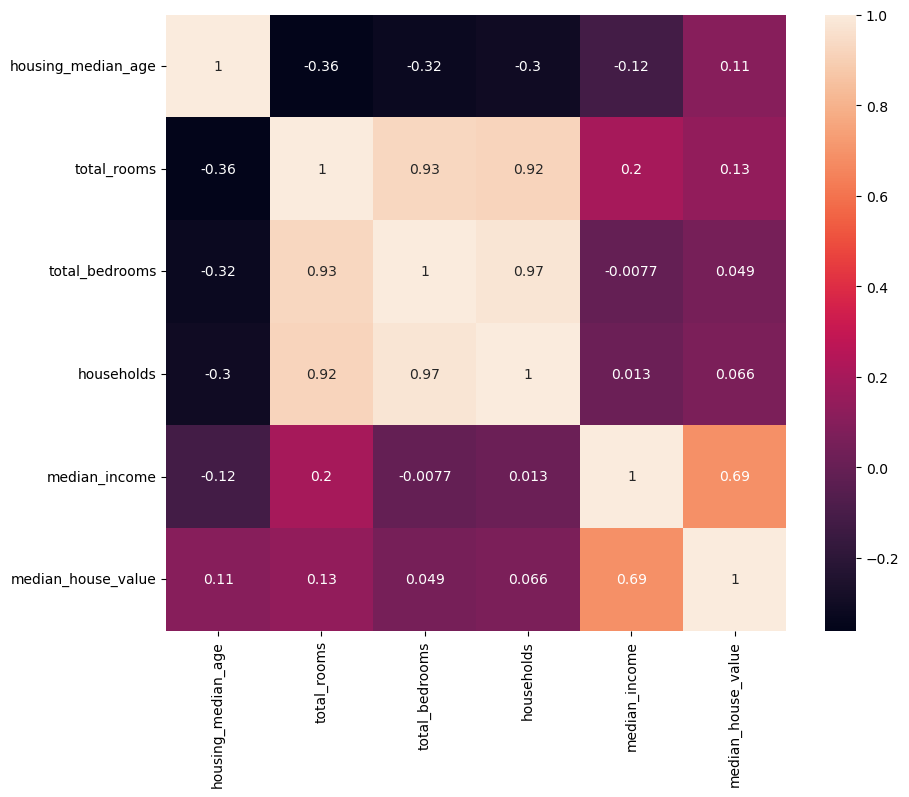

In [30]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()